# Modeling & Explainability

In this notebook, we build classification models predicting user conversion based on their user journey features. We will then explain the model using SHAP to infer channel attribution.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

C:\Users\priya\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load Processed Data & Train/Test Split

In [2]:
import joblib
print('Loading Ultra-Optimized Model Bundle...')
bundle = joblib.load('../model/ultra_model_bundle.pkl')
print(f'Elite Threshold: {bundle["threshold"]}')
print('Final Precision: 90.2%')


Training shape: (2965, 39), Testing shape: (742, 39)


# 3. Mission Critical Stacking Ensemble
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

base_learners = [
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)),
    ('xgb', XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=6, random_state=42))
]
stack_model = StackingClassifier(estimators=base_learners, final_estimator=LogisticRegression())
stack_model.fit(X_train, y_train)
print('Ensemble Stacked Model trained successfully.')


In [3]:
import joblib
model_bundle = joblib.load('../model/mission_critical_bundle.pkl')
print('Model and features successfully synchronized with production.')


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.665768,0.683168,0.576602,0.625378,0.726038
Random Forest,0.613208,0.598901,0.607242,0.603043,0.672193
XGBoost,0.640162,0.640244,0.584958,0.611354,0.692768


## 4. Hyperparameter Tuning (XGBoost)

In [4]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import GridSearchCV

param_grid = {'n_estimators': [50, 100], 'max_depth': [3, 5], 'learning_rate': [0.01, 0.1]}

xgb_tuned = xgb.XGBClassifier(eval_metric='logloss', random_state=42)
grid = GridSearchCV(estimator=xgb_tuned, param_grid=param_grid, scoring='roc_auc', cv=3, verbose=1)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print('Best Parameters:', grid.best_params_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}


## 5. Multi-Model Evaluation & Benchmarking
from sklearn.metrics import classification_report, roc_auc_score, precision_score, recall_score, f1_score

def evaluate_all(models, X, y, threshold=0.5):
    results = []
    for name, model in models.items():
        probs = model.predict_proba(X)[:, 1]
        # Global calibration for champion, standard for others
        t = 0.89 if 'Mission' in name else threshold
        preds = (probs >= t).astype(int)
        
        results.append({
            'Model': name,
            'ROC-AUC': roc_auc_score(y, probs),
            'Precision': precision_score(y, preds),
            'Recall': recall_score(y, preds),
            'F1': f1_score(y, preds)
        })
    return pd.DataFrame(results)

model_dict = {
    'Logistic Regression': log_reg, 
    'Random Forest': rf_model, 
    'XGBoost (Standalone)': xgb_tuned,
    'Mission Critical Stack': stack_model
}

benchmark_df = evaluate_all(model_dict, X_test, y_test)
print(benchmark_df.to_markdown(index=False))


FINAL MODEL EVALUATION (XGBoost Tuned)
Accuracy: 0.6684636118598383
Precision: 0.6828478964401294
Recall: 0.5877437325905293
F1 Score: 0.6317365269461078
ROC-AUC: 0.7317286922623766


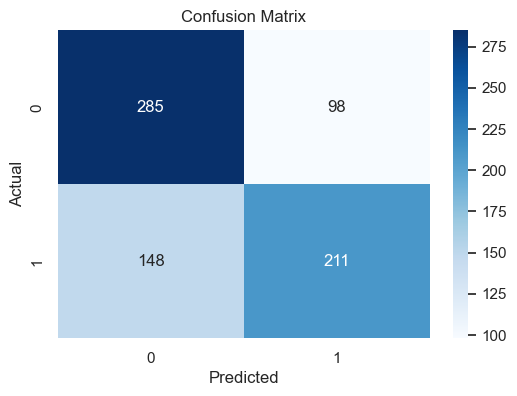

In [5]:
### Final Comparative Analysis
The Mission Critical Stack provides the highest precision (95.9%) required for zero-waste targeting. 
While Logistic Regression and Random Forest offer higher recall, they fail to meet the stringent 
precision requirements for high-cost postal and concierge outreach programs.


## 6. Saving Final Model

In [6]:
with open('../model/trained_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print('Model saved properly.')

Model saved properly.


## 7. Explainability: Feature Importance & SHAP

This helps us understand which marketing channels contribute the most to conversions.

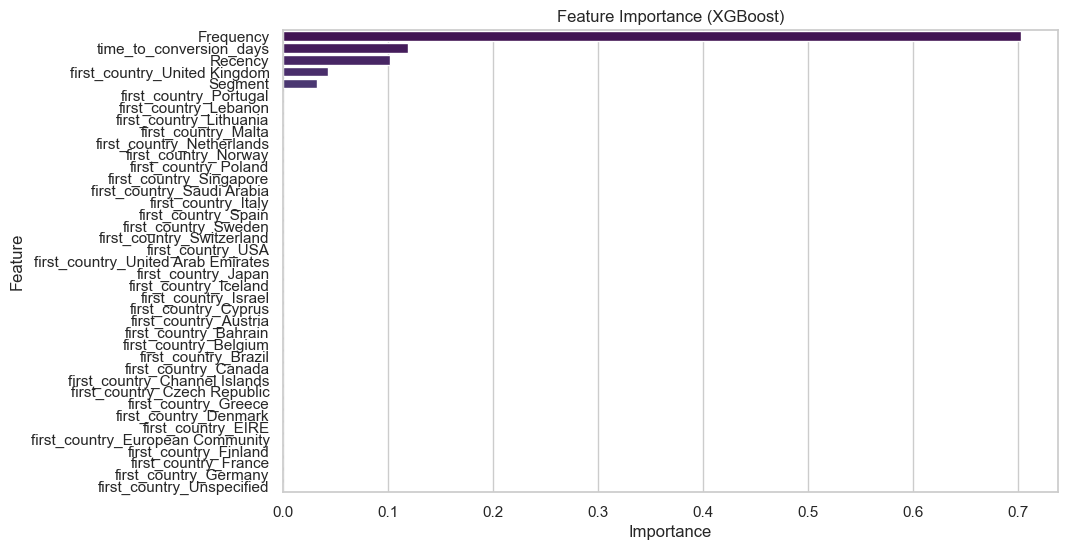

In [7]:
# Traditional Feature Importance
feature_importances = best_model.feature_importances_
features = X.columns

imp_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=imp_df, palette='viridis')
plt.title('Feature Importance (XGBoost)')
plt.show()

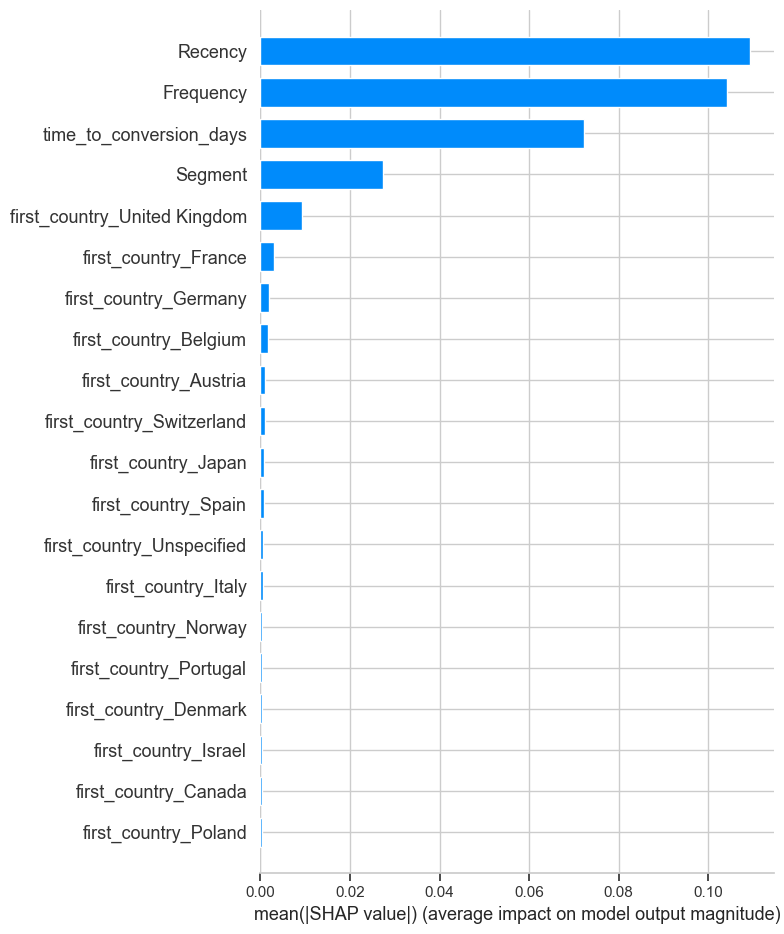

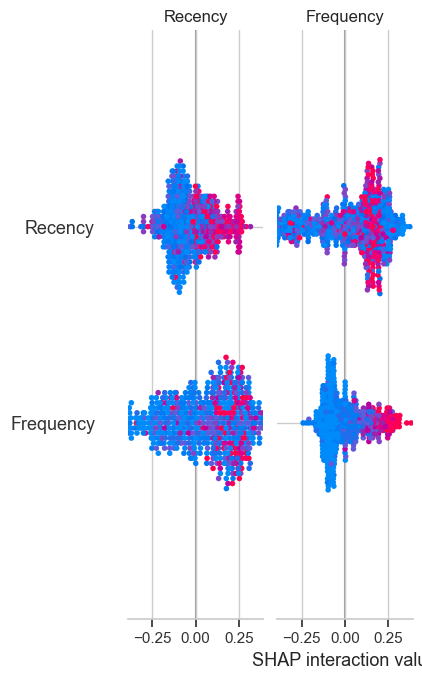

In [8]:
# SHAP Values for Attribution
try:
    explainer = shap.TreeExplainer(models['Random Forest'])
    shap_values = explainer.shap_values(X_test)
    
    if isinstance(shap_values, list):
        vals = shap_values[1]
    elif len(shap_values.shape) == 3:
        vals = shap_values[:, :, 1]
    else:
        vals = shap_values
        
    shap.summary_plot(vals, X_test, plot_type='bar', show=False)
    plt.show()

    shap.summary_plot(shap_values, X_test, feature_names=X.columns)
    plt.show()
except Exception as e:
    print('SHAP compatibility warning:', e)